# FindIT 2025 â€” Face Anti-Spoofing

6-class classification: `realperson`, `fake_printed`, `fake_screen`, `fake_mask`, `fake_mannequin`, `fake_unknown`

**Strategy:** DINOv2-with-registers-base + LoRA (Phase 1) â†’ ensemble with EfficientNetV2-S (Phase 2) â†’ 4-way TTA at inference

**Metric:** Macro F1-Score | **Train:** 1,652 images | **Test:** 404 images

> **Kaggle/local:** Enable internet at least once to download pretrained models, lalu bisa pakai cache lokal.

In [1]:
# !pip install -q "Pillow<10.0.0" "transformers>=4.35.0" "peft>=0.7.0" "timm>=0.9.0" "facenet-pytorch>=2.5.3" "huggingface_hub>=0.20.0"

In [2]:
import os, io, json, warnings
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast                       # available since PyTorch 2.0
try:
    from torch.amp import GradScaler                 # PyTorch >= 2.3
except ImportError:
    from torch.cuda.amp import GradScaler            # PyTorch  2.2
import torchvision.transforms as T
from PIL import Image

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, classification_report

from transformers import AutoModel
from peft import LoraConfig, get_peft_model
import timm
from facenet_pytorch import MTCNN

warnings.filterwarnings('ignore')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

c:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\google\api_core\_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.0) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


Device: cuda


In [3]:
# import torch
# DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# print("DEVICE:", DEVICE)
# print("GPU:", torch.cuda.get_device_name(DEVICE))

# # Force a GPU operation to confirm it works
# x = torch.randn(1000, 1000).to(DEVICE)
# y = x @ x
# print("GPU test passed, result shape:", y.shape)
# print("GPU memory used:", torch.cuda.memory_allocated(DEVICE) / 1e6, "MB")


In [4]:
# Kaggle: adjust the dataset name to match your uploaded dataset slug
if Path('/kaggle/working').exists():
    TRAIN_DIR = Path('train')
    TEST_DIR  = Path('test')
    OUT_DIR   = Path('./')
else:
    TRAIN_DIR = Path('train')
    TEST_DIR  = Path('test')
    OUT_DIR   = Path('output')

OUT_DIR.mkdir(parents=True, exist_ok=True)
(OUT_DIR / 'checkpoints').mkdir(exist_ok=True)

LABEL_MAP = {
    'realperson': 0, 'fake_printed': 1, 'fake_screen': 2,
    'fake_mask': 3,  'fake_mannequin': 4, 'fake_unknown': 5,
}
IDX_TO_LABEL = {v: k for k, v in LABEL_MAP.items()}
NUM_CLASSES  = 6

CFG = dict(
    seed=42, n_folds=5, img_size=224, expand_ratio=1.5,

    # DINOv2-Large with Registers
    dinov2_name='facebook/dinov2-with-registers-large',
    d_epochs=30, d_bs=16, d_lr_head=1e-4, d_lr_bb=2e-6,
    d_wd=0.01, d_warmup=3, d_patience=7,
    lora_r=32, lora_alpha=64, lora_dropout=0.05,

    # Loss
    focal_gamma=2.0, label_smoothing=0.05,
)

torch.manual_seed(CFG["seed"])
np.random.seed(CFG["seed"])
print('Config ready.')


Config ready.


In [5]:
from huggingface_hub import snapshot_download

HF_MODEL_DIR = OUT_DIR / 'hf_models'
HF_MODEL_DIR.mkdir(parents=True, exist_ok=True)


def ensure_local_hf_model(repo_candidates, local_dir):
    local_dir = Path(local_dir)
    if local_dir.exists() and any(local_dir.iterdir()):
        print(f'HF cache found: {local_dir}')
        return str(local_dir), None

    last_err = None
    for repo_id in repo_candidates:
        try:
            print(f'Downloading {repo_id} -> {local_dir} ...')
            snapshot_download(
                repo_id=repo_id,
                local_dir=str(local_dir),
                local_dir_use_symlinks=False,
                resume_download=True,
            )
            print('Download complete.')
            return str(local_dir), repo_id
        except Exception as e:
            last_err = e

    raise RuntimeError(
        f'Failed to download HF model. Tried: {repo_candidates}. Last error: {last_err}'
    )


# DINOv2-Large with Registers
dino_repos = [
    CFG['dinov2_name'],
    'facebook/dinov2-with-registers-large',
    'facebook/dinov2-large',
]
CFG['dinov2_local_dir'], used_repo = ensure_local_hf_model(
    dino_repos,
    HF_MODEL_DIR / 'dinov2_with_registers_large',
)
if used_repo is not None:
    CFG['dinov2_name'] = used_repo
print('CFG["dinov2_local_dir"] =', CFG['dinov2_local_dir'])
print('CFG["dinov2_name"] =', CFG['dinov2_name'])


Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

.gitattributes: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

Download complete.
CFG["dinov2_local_dir"] = output\hf_models\dinov2_with_registers_large
CFG["dinov2_name"] = facebook/dinov2-with-registers-large


## Download Backbones to Local Cache
Jalankan sekali untuk mengunduh backbone **DINOv2** dan **EfficientNetV2-S** ke folder lokal agar training/inference bisa jalan lebih stabil.

## EDA

Total training images: 1652
label
realperson        486
fake_unknown      308
fake_mask         282
fake_mannequin    210
fake_screen       203
fake_printed      163


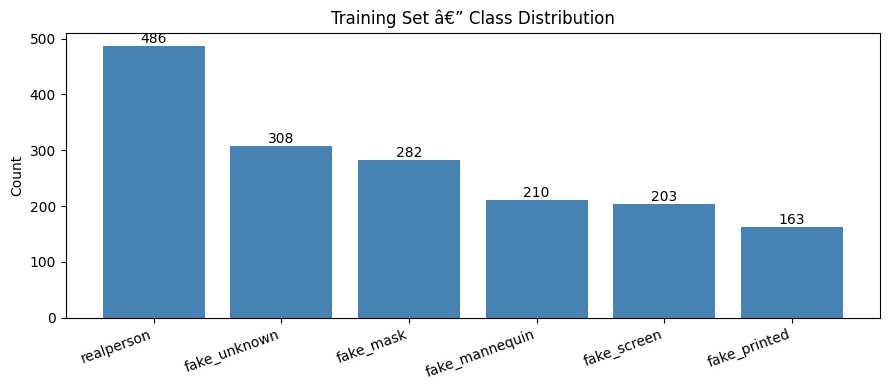

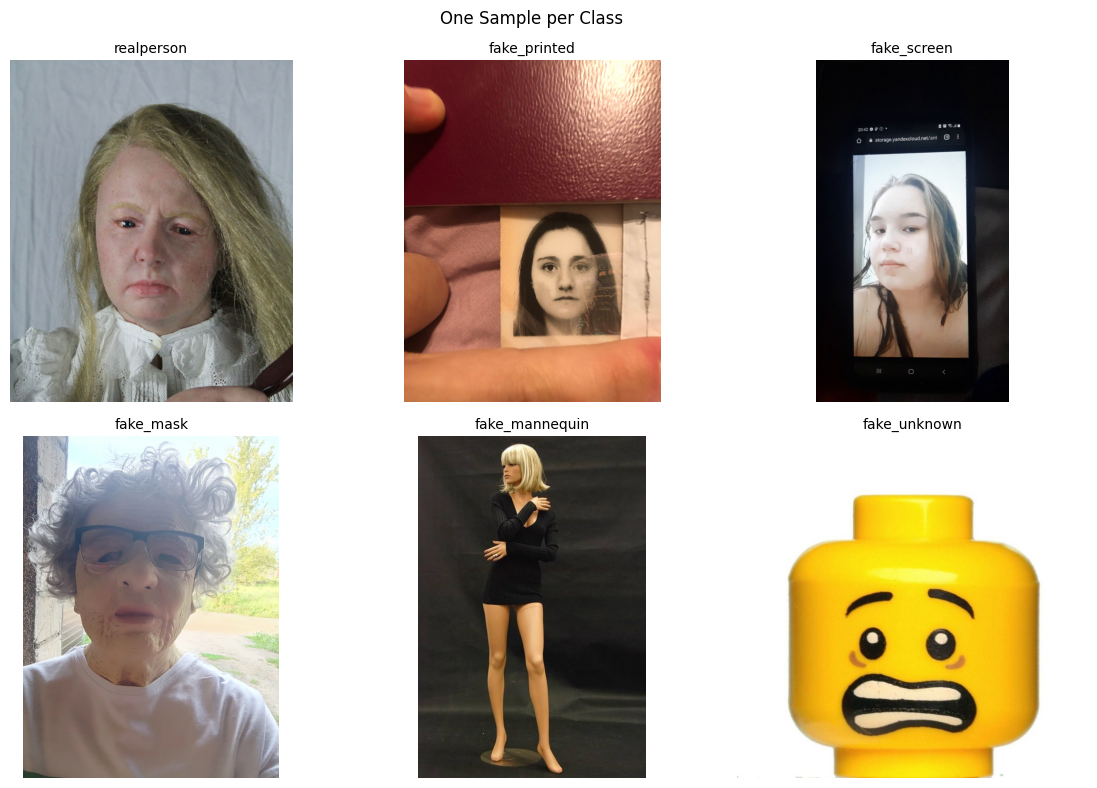

In [6]:
records = []
for cls_dir in sorted(TRAIN_DIR.iterdir()):
    if cls_dir.is_dir() and cls_dir.name in LABEL_MAP:
        for p in sorted(cls_dir.glob('*.jpg')) + sorted(cls_dir.glob('*.jpeg')) + sorted(cls_dir.glob('*.png')):
            records.append({'path': str(p), 'label': cls_dir.name,
                            'label_idx': LABEL_MAP[cls_dir.name]})

train_df = pd.DataFrame(records)
print(f'Total training images: {len(train_df)}')
print(train_df['label'].value_counts().to_string())

fig, ax = plt.subplots(figsize=(9, 4))
counts = train_df['label'].value_counts()
bars = ax.bar(counts.index, counts.values, color='steelblue')
ax.bar_label(bars)
ax.set_title('Training Set â€” Class Distribution')
ax.set_ylabel('Count')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for ax, label in zip(axes.flat, LABEL_MAP):
    row = train_df[train_df['label'] == label].iloc[0]
    ax.imshow(Image.open(row['path']))
    ax.set_title(label, fontsize=10)
    ax.axis('off')
plt.suptitle('One Sample per Class')
plt.tight_layout()
plt.show()


## Face Detection (MTCNN)
Runs once and caches bounding boxes to `output/bbox_cache.json`.

In [7]:
def detect_faces(train_dir, test_dir, cache_path, device):
    if Path(cache_path).exists():
        print(f'Loading cached detections: {cache_path}')
        with open(cache_path) as f:
            return json.load(f)

    mtcnn = MTCNN(keep_all=False, device=device, select_largest=True,
                  post_process=False, min_face_size=20)
    paths = list(Path(train_dir).rglob('*.jpg')) + list(Path(test_dir).glob('*.jpg'))
    cache = {}
    for img_path in tqdm(paths, desc='Detecting faces'):
        key = str(img_path)
        try:
            img = Image.open(img_path).convert('RGB')
            boxes, _ = mtcnn.detect(img)
            if boxes is not None and len(boxes) > 0:
                cache[key] = [int(v) for v in boxes[0]]   # [x1, y1, x2, y2]
            else:
                cache[key] = None                          # fallback: full image
        except Exception:
            cache[key] = None
    with open(cache_path, 'w') as f:
        json.dump(cache, f)
    detected = sum(1 for v in cache.values() if v is not None)
    print(f'Detected {detected}/{len(paths)} faces ({detected/len(paths)*100:.1f}%)')
    return cache

BBOX_CACHE = detect_faces(TRAIN_DIR, TEST_DIR, OUT_DIR / 'bbox_cache.json', DEVICE)


Loading cached detections: output\bbox_cache.json


In [8]:
## Precompute & Cache Cropped Images as Tensors
# Runs once. Saves tight + expanded crops for every train/test image to output/tensor_cache/.
# __getitem__ then just loads a tensor — zero disk I/O overhead during training.

import torchvision.transforms.functional as TF

TENSOR_CACHE = OUT_DIR / 'tensor_cache'
TENSOR_CACHE.mkdir(exist_ok=True)

def _save_crop(img_path, bbox_cache, expand, out_dir, size=224):
    key = f'{Path(img_path).stem}_exp{str(expand).replace(".","p")}.pt'
    out_path = out_dir / key
    if out_path.exists():
        return str(out_path)
    img = Image.open(img_path).convert('RGB')
    img = crop_face(img, bbox_cache.get(str(img_path)), expand)
    img = img.resize((size, size), Image.BILINEAR)
    t   = TF.to_tensor(img)   # float32 [0,1], shape (3,H,W)
    torch.save(t, out_path)
    return str(out_path)

def build_tensor_cache(paths, bbox_cache, cfg):
    tight_paths, exp_paths = [], []
    for p in tqdm(paths, desc='Caching tensors'):
        tight_paths.append(_save_crop(p, bbox_cache, 1.0, TENSOR_CACHE, cfg['img_size']))
        exp_paths.append(  _save_crop(p, bbox_cache, cfg['expand_ratio'], TENSOR_CACHE, cfg['img_size']))
    return tight_paths, exp_paths

all_img_paths = train_df['path'].tolist() + sorted([str(p) for p in TEST_DIR.glob('*.jpg')] + [str(p) for p in TEST_DIR.glob('*.jpeg')] + [str(p) for p in TEST_DIR.glob('*.png')], key=lambda s: Path(s).stem)
TIGHT_CACHE, EXP_CACHE = build_tensor_cache(all_img_paths, BBOX_CACHE, CFG)
print(f'Tensor cache ready: {len(TIGHT_CACHE)} tight + {len(EXP_CACHE)} expanded crops saved.')


Caching tensors:   0%|          | 0/2056 [00:00<?, ?it/s]

Tensor cache ready: 2056 tight + 2056 expanded crops saved.


## Dataset & Transforms

In [9]:
def crop_face(img, bbox, expand=1.0):
    """Crop face bounding box, expanded by factor. Returns full image if no bbox."""
    if bbox is None:
        return img
    w, h = img.size
    x1, y1, x2, y2 = bbox
    cx, cy   = (x1 + x2) / 2, (y1 + y2) / 2
    bw, bh   = (x2 - x1) * expand, (y2 - y1) * expand
    x1 = max(0, int(cx - bw / 2));  x2 = min(w, int(cx + bw / 2))
    y1 = max(0, int(cy - bh / 2));  y2 = min(h, int(cy + bh / 2))
    return img.crop((x1, y1, x2, y2)) if x2 > x1 and y2 > y1 else img


MEAN, STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
_normalize = T.Normalize(MEAN, STD)

# Augmentation-only transforms (tensor already resized to img_size)
def train_tfm_aug():
    """Applied to a float32 [0,1] tensor (C,H,W) from the cache."""
    return T.Compose([
        T.RandomHorizontalFlip(0.5),
        T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
        T.RandomRotation(15),
        T.RandomGrayscale(0.1),
        T.RandomErasing(p=0.3, scale=(0.02, 0.15)),
        _normalize,
    ])

def val_tfm_aug(hflip=False):
    ops = ([T.RandomHorizontalFlip(p=1.0)] if hflip else []) + [_normalize]
    return T.Compose(ops)


class FASDataset(Dataset):
    """Loads pre-saved tensor crops — no disk JPEG decode or resize at runtime."""
    def __init__(self, tensor_paths, labels, transform):
        self.tensor_paths = tensor_paths
        self.labels       = labels
        self.tfm          = transform
    def __len__(self): return len(self.tensor_paths)
    def __getitem__(self, i):
        t   = torch.load(self.tensor_paths[i], weights_only=True)  # float32 [0,1]
        lbl = self.labels[i] if self.labels is not None else -1
        return self.tfm(t), lbl

# Sanity check (requires TIGHT_CACHE from precompute cell)
_img, _ = FASDataset([TIGHT_CACHE[0]], [train_df.iloc[0]['label_idx']], val_tfm_aug())[0]
assert _img.shape == (3, 224, 224), f'Bad shape: {_img.shape}'
print(f'FASDataset OK — shape: {_img.shape}')


FASDataset OK — shape: torch.Size([3, 224, 224])


## Focal Loss + Class Weights

In [10]:
def compute_class_weights(labels, n=NUM_CLASSES):
    """Inverse-frequency weights: minority classes get higher weight.
    sqrt smoothing prevents extreme values for very rare classes.
    """
    counts = torch.zeros(n)
    for l in labels: counts[l] += 1
    total = counts.sum()
    # weight = total / (n_classes * count)  — standard inverse freq
    w = total / (n * counts.clamp(min=1))
    return w.to(DEVICE)


class FocalLoss(nn.Module):
    def __init__(self, alpha, gamma=2.0, smoothing=0.1):
        super().__init__()
        self.register_buffer('alpha', alpha)
        self.gamma, self.smoothing, self.C = gamma, smoothing, len(alpha)

    def forward(self, logits, targets):
        with torch.no_grad():
            soft = torch.full_like(logits, self.smoothing / (self.C - 1))
            soft.scatter_(1, targets.unsqueeze(1), 1.0 - self.smoothing)
        log_p = F.log_softmax(logits, dim=1)
        pt    = (log_p.exp() * soft).sum(1)
        loss  = self.alpha[targets] * (1 - pt) ** self.gamma * -(soft * log_p).sum(1)
        return loss.mean()

# Show weights — smaller class → higher weight
_cw = compute_class_weights(train_df['label_idx'].tolist())
_fl = FocalLoss(_cw)
_v  = _fl(torch.randn(4, NUM_CLASSES, device=DEVICE), torch.randint(0, NUM_CLASSES, (4,), device=DEVICE))
assert not _v.isnan(), 'Loss is NaN'
print('Class weights (higher = rarer class gets more focus):')
for i in range(NUM_CLASSES):
    cnt = (torch.tensor(train_df['label_idx'].tolist()) == i).sum().item()
    print(f'  {IDX_TO_LABEL[i]:<18} count={cnt:>4}  weight={_cw[i]:.4f}')


Class weights (higher = rarer class gets more focus):
  realperson         count= 486  weight=0.5665
  fake_printed       count= 163  weight=1.6892
  fake_screen        count= 203  weight=1.3563
  fake_mask          count= 282  weight=0.9764
  fake_mannequin     count= 210  weight=1.3111
  fake_unknown       count= 308  weight=0.8939


## Model â€” DINOv2-with-registers-base + LoRA (Phase 1)

In [11]:
class DINOv2FAS(nn.Module):
    def __init__(self, cfg, n_classes=NUM_CLASSES):
        super().__init__()

        local_dir = cfg.get('dinov2_local_dir')
        candidates = [
            local_dir,
            cfg['dinov2_name'],
            'facebook/dinov2-with-registers-large',
            'facebook/dinov2-with-registers-base',
            'facebook/dinov2-large',
            'facebook/dinov2-base',
        ]
        seen = set()
        candidates = [m for m in candidates if m and not (m in seen or seen.add(m))]

        bb, used_name, last_err = None, None, None
        for model_name in candidates:
            try:
                bb = AutoModel.from_pretrained(model_name)
                used_name = model_name
                break
            except OSError as e:
                last_err = e

        if bb is None:
            raise OSError(
                'Failed to load DINOv2. '
                'Download the model or check your internet connection. '
                f'Tried: {candidates}. Last error: {last_err}'
            )

        print(f'Using DINOv2 backbone: {used_name}')
        hidden = bb.config.hidden_size

        lora_cfg = LoraConfig(
            r=cfg['lora_r'], lora_alpha=cfg['lora_alpha'],
            lora_dropout=cfg['lora_dropout'],
            target_modules=['query', 'key', 'value', 'out_proj'],
            bias='none',
        )
        self.backbone = get_peft_model(bb, lora_cfg)
        self.backbone.print_trainable_parameters()

        self.head = nn.Sequential(
            nn.LayerNorm(hidden * 2),
            nn.Linear(hidden * 2, 512), nn.GELU(), nn.Dropout(0.3),
            nn.Linear(512, n_classes),
        )

    def forward(self, x):
        out = self.backbone(pixel_values=x)
        cls = out.last_hidden_state[:, 0]
        gap = out.last_hidden_state[:, 1:].mean(1)
        return self.head(torch.cat([cls, gap], 1))

# Forward pass check
_m = DINOv2FAS(CFG).to(DEVICE)
with torch.no_grad():
    _o = _m(torch.randn(2, 3, 224, 224).to(DEVICE))
assert _o.shape == (2, NUM_CLASSES)
print(f'DINOv2FAS OK — output: {_o.shape}')
del _m; torch.cuda.empty_cache()


Using DINOv2 backbone: output\hf_models\dinov2_with_registers_large
trainable params: 4,718,592 || all params: 309,091,328 || trainable%: 1.5266
DINOv2FAS OK — output: torch.Size([2, 6])


## Model â€” EfficientNetV2-S (Phase 2)

In [12]:
# EfficientNet removed — using single DINOv2 model.
print('EfficientNet disabled — single DINOv2 model mode.')


EfficientNet disabled — single DINOv2 model mode.


## Training Utilities

In [13]:
def run_epoch(model, loader, optimizer, scaler, criterion, device, train=True):
    model.train(train)
    total_loss, preds, lbls = 0.0, [], []
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for imgs, labels in tqdm(loader, leave=False):
            imgs, labels = imgs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
            if train: optimizer.zero_grad()
            with autocast(device.type):
                logits = model(imgs)
                loss   = criterion(logits, labels)
            if train:
                scaler.scale(loss).backward()
                scaler.step(optimizer); scaler.update()
            total_loss += loss.item()
            preds.extend(logits.argmax(1).cpu().numpy())
            lbls.extend(labels.cpu().numpy())
    return total_loss / len(loader), f1_score(lbls, preds, average='macro', zero_division=0)


def dual_crop_probs(model, loader_tight, loader_exp, device):
    """Average softmax probs from tight + expanded crop loaders (same order, no shuffle)."""
    model.eval()
    all_probs = []
    with torch.no_grad():
        for (imgs_t, _), (imgs_e, _) in zip(loader_tight, loader_exp):
            imgs_t, imgs_e = imgs_t.to(device, non_blocking=True), imgs_e.to(device, non_blocking=True)
            with autocast(device.type):
                logits = (model(imgs_t) + model(imgs_e)) / 2
            all_probs.append(F.softmax(logits, 1).cpu().numpy())
    return np.vstack(all_probs)


def _get_tensor_cache_maps():

    if 'all_img_paths' not in globals() or 'TIGHT_CACHE' not in globals() or 'EXP_CACHE' not in globals():
        raise RuntimeError('Tensor cache not ready. Run the precompute tensor cache cell first.')

    if len(all_img_paths) != len(TIGHT_CACHE) or len(all_img_paths) != len(EXP_CACHE):
        raise RuntimeError('Tensor cache size mismatch. Please rebuild tensor cache.')

    globals()['PATH_TO_TIGHT'] = {str(p).replace(os.sep, '/'): t for p, t in zip(all_img_paths, TIGHT_CACHE)}
    globals()['PATH_TO_EXP'] = {str(p).replace(os.sep, '/'): t for p, t in zip(all_img_paths, EXP_CACHE)}
    return PATH_TO_TIGHT, PATH_TO_EXP


def make_loaders(paths, labels, cfg, bs, tr_idx, vl_idx):
    p2t, p2e = _get_tensor_cache_maps()

    tp = [str(paths[i]).replace(os.sep, '/') for i in tr_idx]
    vp = [str(paths[i]).replace(os.sep, '/') for i in vl_idx]
    tl = [labels[i] for i in tr_idx]
    vl = [labels[i] for i in vl_idx]

    tr_exp = [p2e[p] for p in tp]
    vl_tight = [p2t[p] for p in vp]
    vl_exp = [p2e[p] for p in vp]

    # Windows + Jupyter: multiprocessing workers crash outside __main__.
    # num_workers=0 runs loading in the main process — safe and still fast
    # because images are pre-saved as .pt tensors (no heavy CPU work per batch).
    import platform
    nw = 0 if platform.system() == 'Windows' else 4
    kw = dict(num_workers=nw, pin_memory=(nw == 0))
    tr  = DataLoader(FASDataset(tr_exp,   tl, train_tfm_aug()), batch_size=bs,   shuffle=True,  **kw)
    vt  = DataLoader(FASDataset(vl_tight, vl, val_tfm_aug()),   batch_size=bs*2, shuffle=False, **kw)
    ve  = DataLoader(FASDataset(vl_exp,   vl, val_tfm_aug()),   batch_size=bs*2, shuffle=False, **kw)
    return tr, vt, ve, tl, vl

## Shared 5-Fold Training Loop

In [14]:
def train_kfold(ModelCls, name, cfg, paths, labels, device):
    """
    Train ModelCls with stratified 5-fold CV.
    Saves checkpoints to output/checkpoints/<name>_f<fold>.pt
    Returns OOF probability array (N, NUM_CLASSES).
    """
    skf = StratifiedKFold(n_splits=cfg['n_folds'], shuffle=True, random_state=cfg['seed'])
    oof = np.zeros((len(paths), NUM_CLASSES))
    cw  = compute_class_weights(labels)
    bs  = cfg['d_bs'] if 'dino' in name else cfg['e_bs']

    for fold, (tr_idx, vl_idx) in enumerate(skf.split(paths, labels)):
        print(f'\n{"="*55}')
        print(f'  {name.upper()}   Fold {fold+1}/{cfg["n_folds"]}')
        print(f'{"="*55}')

        tr_loader, vt_loader, ve_loader, tr_lbls, vl_lbls = \
            make_loaders(paths, labels, cfg, bs, tr_idx, vl_idx)

        model     = ModelCls(cfg).to(device)
        criterion = FocalLoss(cw, gamma=cfg['focal_gamma'], smoothing=cfg['label_smoothing'])
        scaler    = GradScaler(device.type)

        if 'dino' in name:
            optimizer = torch.optim.AdamW([
                {'params': model.head.parameters(),
                 'lr': cfg['d_lr_head']},
                {'params': [p for p in model.backbone.parameters() if p.requires_grad],
                 'lr': cfg['d_lr_bb']},
            ], weight_decay=cfg['d_wd'])
            epochs, patience, warmup = cfg['d_epochs'], cfg['d_patience'], cfg['d_warmup']
        else:
            optimizer = torch.optim.AdamW(model.parameters(), lr=cfg['e_lr'],
                                          weight_decay=cfg['e_wd'])
            epochs, patience, warmup = cfg['e_epochs'], cfg['e_patience'], cfg['e_warmup']

        warmup_sch  = torch.optim.lr_scheduler.LinearLR(
            optimizer, start_factor=0.1, total_iters=warmup)
        cosine_sch  = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=max(1, epochs - warmup), eta_min=1e-7)

        best_f1, no_improve = 0.0, 0
        ckpt = OUT_DIR / f'checkpoints/{name}_f{fold}.pt'

        for ep in range(1, epochs + 1):
            tr_loss, tr_f1 = run_epoch(model, tr_loader, optimizer, scaler,
                                        criterion, device, train=True)
            vl_probs = dual_crop_probs(model, vt_loader, ve_loader, device)
            vl_f1    = f1_score(vl_lbls, vl_probs.argmax(1), average='macro', zero_division=0)

            (warmup_sch if ep <= warmup else cosine_sch).step()
            print(f'  Ep {ep:03d} | tr_loss={tr_loss:.4f} tr_f1={tr_f1:.4f} | val_f1={vl_f1:.4f}')

            if vl_f1 > best_f1:
                best_f1, no_improve = vl_f1, 0
                torch.save(model.state_dict(), ckpt)
            else:
                no_improve += 1
                if no_improve >= patience:
                    print(f'  Early stopping at epoch {ep}')
                    break

        model.load_state_dict(torch.load(ckpt, map_location=device, weights_only=True))
        fold_probs   = dual_crop_probs(model, vt_loader, ve_loader, device)
        oof[vl_idx]  = fold_probs
        fold_oof_f1  = f1_score(vl_lbls, fold_probs.argmax(1), average='macro', zero_division=0)
        print(f'  Fold {fold+1} best val F1: {best_f1:.4f}  |  OOF F1: {fold_oof_f1:.4f}')
        del model; torch.cuda.empty_cache()

    overall = f1_score(labels, oof.argmax(1), average='macro', zero_division=0)
    print(f'\n>>> {name.upper()} Overall OOF Macro F1: {overall:.4f}')
    print(classification_report([IDX_TO_LABEL[l] for l in labels],
                                 [IDX_TO_LABEL[i] for i in oof.argmax(1)],
                                 zero_division=0))
    np.save(OUT_DIR / f'{name}_oof.npy', oof)
    return oof

## Phase 1 Train DINOv2 + LoRA

Expected OOF Macro F1 0.85

In [ ]:
ALL_PATHS  = train_df['path'].tolist()
ALL_LABELS = train_df['label_idx'].tolist()

dinov2_oof = train_kfold(DINOv2FAS, 'dinov2', CFG,
                          ALL_PATHS, ALL_LABELS, DEVICE)



  DINOV2   Fold 1/5
Using DINOv2 backbone: output\hf_models\dinov2_with_registers_large
trainable params: 4,718,592 || all params: 309,091,328 || trainable%: 1.5266


  0%|          | 0/83 [00:00<?, ?it/s]

  Ep 001 | tr_loss=1.0273 tr_f1=0.4798 | val_f1=0.6543


  0%|          | 0/83 [00:00<?, ?it/s]

  Ep 002 | tr_loss=0.5161 tr_f1=0.7682 | val_f1=0.8146


...

  0%|          | 0/83 [00:00<?, ?it/s]

  Ep 001 | tr_loss=1.0539 tr_f1=0.4274 | val_f1=0.7607


  0%|          | 0/83 [00:00<?, ?it/s]

  Ep 002 | tr_loss=0.5483 tr_f1=0.7449 | val_f1=0.8721


  0%|          | 0/83 [00:00<?, ?it/s]

## Phase 2 Train EfficientNetV2-S

Expected OOF Macro F1 â‰¥ 0.78

In [ ]:
# EfficientNet training disabled — single DINOv2 model.
print('Skipping EfficientNet training.')
effnet_oof = None


## Tune Ensemble Weights on OOF

In [ ]:
# Single-model: no ensemble tuning needed.
if 'dinov2_oof' not in dir():
    dinov2_oof = np.load(OUT_DIR / 'dinov2_oof.npy')

oof_f1 = f1_score(ALL_LABELS, dinov2_oof.argmax(1), average='macro', zero_division=0)
print(f'DINOv2 OOF Macro F1: {oof_f1:.4f}')
print(classification_report(ALL_LABELS, dinov2_oof.argmax(1),
                             target_names=list(LABEL_MAP.keys()), zero_division=0))


## Inference â€” 4-way TTA + Ensemble + Submission

In [ ]:
def tta_inference(ModelCls, name, test_paths, cfg, device):
    """
    For each fold checkpoint: run 4 TTA passes (tight/expanded x orig/hflip),
    average all fold x TTA predictions.
    """
    import platform
    nw = 0 if platform.system() == 'Windows' else 4
    p2t, p2e = _get_tensor_cache_maps()
    test_paths = [str(p).replace(os.sep, '/') for p in test_paths]
    test_tight = [p2t[p] for p in test_paths]
    test_exp   = [p2e[p] for p in test_paths]

    avg_probs = None
    for fold in range(cfg['n_folds']):
        ckpt  = OUT_DIR / f'checkpoints/{name}_f{fold}.pt'
        model = ModelCls(cfg).to(device)
        model.load_state_dict(torch.load(ckpt, map_location=device, weights_only=True))
        model.eval()

        fold_probs = None
        for tensor_paths in (test_tight, test_exp):
            for hflip in (False, True):
                ds     = FASDataset(tensor_paths, None, val_tfm_aug(hflip=hflip))
                loader = DataLoader(ds, batch_size=32, shuffle=False,
                                    num_workers=nw, pin_memory=(nw == 0))
                batch_probs = []
                with torch.no_grad():
                    for imgs, _ in loader:
                        with autocast(device.type):
                            logits = model(imgs.to(device, non_blocking=True))
                        batch_probs.append(F.softmax(logits, 1).cpu().numpy())
                combo = np.vstack(batch_probs)
                fold_probs = combo if fold_probs is None else fold_probs + combo

        fold_probs /= 4   # 4 TTA combinations
        avg_probs = fold_probs if avg_probs is None else avg_probs + fold_probs
        del model; torch.cuda.empty_cache()

    return avg_probs / cfg['n_folds']


# Gather test paths (sorted by filename for deterministic order)
test_paths = sorted([str(p) for p in TEST_DIR.glob('*.jpg')] +
                    [str(p) for p in TEST_DIR.glob('*.jpeg')] +
                    [str(p) for p in TEST_DIR.glob('*.png')],
                    key=lambda s: Path(s).stem)
print(f'Test images: {len(test_paths)}')

print('Running DINOv2 inference + TTA...')
test_probs = tta_inference(DINOv2FAS, 'dinov2', test_paths, CFG, DEVICE)
test_preds = test_probs.argmax(1)

# Build submission CSV
sub = pd.DataFrame({
    'id':    [Path(p).stem for p in test_paths],
    'label': [IDX_TO_LABEL[i] for i in test_preds],
})
sub.to_csv(OUT_DIR / 'submission.csv', index=False)

print(f'Submission saved to {OUT_DIR}/submission.csv')
print(sub['label'].value_counts().to_string())
print('First 10 rows:')
print(sub.head(10).to_string(index=False))